# Campaign 1.1

The purpose of this notebook is to verify that the L1 .fits files contain all of the data from the .dat files from 9/16 and 9/17, taken during Campaign 1.1 of commissioning. 

Last updated 09-27-2025. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

import astropy.units as u
from astropy.io import fits
from astropy.table import conf
from astropy.time import Time
from astropy.timeseries import TimeSeries

import padre_meddea.io.file_tools as file_tools
from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.housekeeping import calibration
from padre_meddea.util import validation
from padre_meddea.util.util import is_consecutive

from padre_meddea.io.file_tools import read_file

import padre_meddea.calibration.calibration as calibration
from padre_meddea.housekeeping import calibration

In [26]:
raw_data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/commissioning_data/raw")
fits_data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/commissioning_data")

In [20]:
# Read in the data.
# Start with the raw data.
hk_files =['padreMDU8_250915213728.dat',
           'padreMDU8_250916215028.dat',
           'padreMDU8_250917042330.dat',
           'padreMDU8_250917060741.dat',
           'padreMDU8_250917074131.dat',
           'padreMDU8_250917092240.dat',
           'padreMDU8_250917105030.dat',
           'padreMDU8_250919172602.dat']

# Check that the L1 fits files contain all of the data by comparing them to the raw data.
l1_hk_files = ['padre_meddea_l1_housekeeping_20250915T000000_v1.0.1.fits',
               'padre_meddea_l1_housekeeping_20250916T000000_v1.0.0.fits',
               'padre_meddea_l1_housekeeping_20250917T000000_v1.0.1.fits',
               'padre_meddea_l1_housekeeping_20250919T000000_v1.0.0.fits']

In [21]:
with fits.open(fits_data_dir / 'padre_meddea_l1_housekeeping_20250917T000000_v1.0.1.fits') as hdul:
    print(hdul['PROVENANCE'].data)

[('padre_meddea_l0_housekeeping_20250917T042336_v1.0.1.fits', '2025-09-17T04:23:36.000', '2025-09-17T04:23:36.000')
 ('padre_meddea_l0_housekeeping_20250917T042336_v1.0.2.fits', '2025-09-17T04:23:36.000', '2025-09-17T04:23:36.000')
 ('padre_meddea_l0_housekeeping_20250917T060746_v1.0.1.fits', '2025-09-17T06:07:46.000', '2025-09-17T06:07:46.000')
 ('padre_meddea_l0_housekeeping_20250917T060746_v1.0.2.fits', '2025-09-17T06:07:46.000', '2025-09-17T06:07:46.000')
 ('padre_meddea_l0_housekeeping_20250917T074136_v1.0.1.fits', '2025-09-17T07:41:36.000', '2025-09-17T07:41:36.000')
 ('padre_meddea_l0_housekeeping_20250917T074136_v1.0.2.fits', '2025-09-17T07:41:36.000', '2025-09-17T07:41:36.000')
 ('padre_meddea_l0_housekeeping_20250917T092245_v1.0.1.fits', '2025-09-17T09:22:45.000', '2025-09-17T09:22:45.000')
 ('padre_meddea_l0_housekeeping_20250917T092245_v1.0.2.fits', '2025-09-17T09:22:45.000', '2025-09-17T09:22:45.000')
 ('padre_meddea_l0_housekeeping_20250917T105035_v1.0.0.fits', '2025-09-1

In [27]:
for this_file in hk_files:
    print(raw_data_dir / this_file)
    print(validation.validate_packet_checksums(raw_data_dir / this_file))
    print(validation.validate(raw_data_dir / this_file))

C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250915213728.dat
[]
[]
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250916215028.dat
[]
['UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)', 'UserWarning: File appears truncated - missing 1 bytes (or maybe garbage at end)']
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250917042330.dat
[]


c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)


[]
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250917060741.dat
[]
[]
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250917074131.dat
[]
[]
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250917092240.dat
[]
[]
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250917105030.dat
[]


c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:75: UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header
  warnings.warn(
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)
  warnings.warn(message)


['UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header', 'UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)']
C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\raw\padreMDU8_250919172602.dat
[]
[]


Check the data from 09/15. Want to compare the number of packets in the .dat data file with the number of packets in the corresponding L1 .fits file. 

In [ ]:
hk_ts, cmd_ts = read_file(raw_data_dir / hk_files[0])

2025-10-28 11:35:20 - swxsoc - INFO: padreMDU8_250915213728.dat: Found housekeeping data


INFO: padreMDU8_250915213728.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


In [40]:
hk_ts

time,CCSDS_VERSION_NUMBER,CCSDS_PACKET_TYPE,CCSDS_SECONDARY_FLAG,CCSDS_APID,CCSDS_SEQUENCE_FLAG,CCSDS_SEQUENCE_COUNT,CCSDS_PACKET_LENGTH,pkttimes,fp_temp,dib_temp,hvps_temp,hvps_vsense,hvps_csense,csense_15v,csense_33vd,csense_33va,hit_rate,good_cmd_cnt,error_cnt,heater_pwm_duty_cycle,decimation_rate,error_summary,checksum
Time,uint8,uint8,uint8,uint16,uint8,uint16,uint16,uint32,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16
2025-09-15 21:37:33.000,0,0,0,163,3,1,33,811287458,33904,55058,40960,1103,4240,28168,36674,37046,0,7,0,0,0,0,9532
2025-09-15 21:37:43.000,0,0,0,163,3,2,33,811287468,33905,54978,40975,1102,4240,28160,36675,37052,0,7,0,0,0,0,9453
2025-09-15 21:37:53.000,0,0,0,163,3,3,33,811287478,33919,54880,40992,1087,4239,28143,36675,37049,0,7,0,0,0,0,10225
2025-09-15 21:38:03.000,0,0,0,163,3,4,33,811287488,33920,54769,41006,1102,4240,28169,36671,37051,0,7,0,0,0,0,10006
2025-09-15 21:38:13.000,0,0,0,163,3,5,33,811287498,33924,54672,41021,1102,4240,28167,36675,37046,0,7,0,0,0,0,10004
2025-09-15 21:38:23.000,0,0,0,163,3,6,33,811287508,33932,54567,41039,1099,4240,28167,36673,37045,0,7,0,0,0,0,10176
2025-09-15 21:38:33.000,0,0,0,163,3,7,33,811287518,33936,54465,41054,1097,4240,28166,36671,37037,0,7,0,0,0,0,9797
2025-09-15 21:38:43.000,0,0,0,163,3,8,33,811287528,33936,54370,41067,1099,4240,28168,36673,37042,0,7,0,0,0,0,9863
2025-09-15 21:38:53.000,0,0,0,163,3,9,33,811287538,33942,54287,41082,1099,4240,28169,36669,37039,0,7,0,0,0,0,9862


In [46]:
l1_hk_ts, l1_cmd_ts = read_file(fits_data_dir / l1_hk_files[0])

2025-10-28 11:36:18 - swxsoc - WARNING: No command response data found in C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis\data\commissioning_data\padre_meddea_l1_housekeeping_20250915T000000_v1.0.1.fits


In [47]:
l1_hk_ts

time,pkttimes,fp_temp,dib_temp,hvps_temp,hvps_vsense,hvps_csense,csense_15v,csense_33vd,csense_33va,hit_rate,good_cmd_cnt,error_cnt,heater_pwm_duty_cycle,decimation_rate,error_summary,checksum,seqcount
Time,uint32,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16
2025-09-15 21:37:33.000,811287458,33904,55058,40960,1103,4240,28168,36674,37046,0,7,0,0,0,0,9532,1
2025-09-15 21:37:33.000,811287458,33904,55058,40960,1103,4240,28168,36674,37046,0,7,0,0,0,0,9532,1
2025-09-15 21:37:43.000,811287468,33905,54978,40975,1102,4240,28160,36675,37052,0,7,0,0,0,0,9453,2
2025-09-15 21:37:43.000,811287468,33905,54978,40975,1102,4240,28160,36675,37052,0,7,0,0,0,0,9453,2
2025-09-15 21:37:53.000,811287478,33919,54880,40992,1087,4239,28143,36675,37049,0,7,0,0,0,0,10225,3
2025-09-15 21:37:53.000,811287478,33919,54880,40992,1087,4239,28143,36675,37049,0,7,0,0,0,0,10225,3
2025-09-15 21:38:03.000,811287488,33920,54769,41006,1102,4240,28169,36671,37051,0,7,0,0,0,0,10006,4
2025-09-15 21:38:03.000,811287488,33920,54769,41006,1102,4240,28169,36671,37051,0,7,0,0,0,0,10006,4
2025-09-15 21:38:13.000,811287498,33924,54672,41021,1102,4240,28167,36675,37046,0,7,0,0,0,0,10004,5


In [48]:
print(len(hk_ts['time']), len(l1_hk_ts['time']))

76 152


In [49]:
76*2

152

There are twice as many data in the L1 fits file from 09/15 as in the raw file from 09/15. What is causing this?

In [50]:
hk_ts['time'][0].value, hk_ts['time'][-1].value

('2025-09-15 21:37:33.000', '2025-09-15 21:50:03.000')

Check the data from 09/16. Want to compare the number of packets in the data with the number of packets in the corresponding L1 .fits file. 

In [51]:
hk_ts, cmd_ts = read_file(raw_data_dir / hk_files[1])

c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 11:36:45 - swxsoc - INFO: padreMDU8_250916215028.dat: Found housekeeping data


INFO: padreMDU8_250916215028.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 11:36:46 - swxsoc - INFO: padreMDU8_250916215028.dat: Found read data


INFO: padreMDU8_250916215028.dat: Found read data [padre_meddea.housekeeping.housekeeping]


In [52]:
print(len(hk_ts))

2319


This .dat file includes data from 09/16 and 09/17, but the L1 fits file only contains data from a 24-hour period, ending at 23:59:53 UTC. Hence, we need to determine the number of packets contained in the .dat file for 09/16, before 23:59:53 UTC. Then, we can compare this to the corresponding L1 fits file. 

In [53]:
# Set the start time 10s before the desired start time, since the endpoint is not inclusive. 
good_tr = [(Time('2025-09-16T21:50:23'), Time('2025-09-16T23:59:53'))] 

In [54]:
mask = ((hk_ts.time >= good_tr[0][0].value) & (hk_ts.time <= good_tr[0][1].value))

In [55]:
hk_ts['time'][mask][0].value, hk_ts['time'][mask][-1].value

('2025-09-16 21:50:33.000', '2025-09-16 23:59:53.000')

In [56]:
len(hk_ts['time'][mask])

777

Now, compare to the L1 data from 09/16. 

In [58]:
l1_hk_ts, l1_cmd_ts = read_file(fits_data_dir / l1_hk_files[1])

In [60]:
len(l1_hk_ts['time']), len(np.unique(l1_hk_ts['time']))

(2331, 777)

BUT, the total length of the l1_hk_ts is 3 times that of the length of the housekeeping data. Each packet repeats 3 times before the sequence counter increments by 1. 

In [ ]:
l1_hk_ts['seqcount']

In [320]:
len(l1_hk_ts['time'])

2331

In [321]:
len(hk_ts['time'][mask])*3

2331

This confirms that there are the same number of (expected) packets in the same times ranges in padreMDU8_250916215028.dat and in padre_meddea_l1_housekeeping_20250916T000000_v1.0.0.fits. The fits files have each packet repeated 3 times in the timeseries. 

Check that there are the same number of packets in the data from 9/17. 

Start by calculating the number of packets in padreMDU8_250916215028.dat from 00:00:03 until the end of the file at 04:16:53.000. 

In [61]:
hk_ts, cmd_ts = read_file(raw_data_dir / hk_files[1])

c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 11:58:55 - swxsoc - INFO: padreMDU8_250916215028.dat: Found housekeeping data


INFO: padreMDU8_250916215028.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 11:58:56 - swxsoc - INFO: padreMDU8_250916215028.dat: Found read data


INFO: padreMDU8_250916215028.dat: Found read data [padre_meddea.housekeeping.housekeeping]


In [62]:
good_tr = [(Time('2025-09-17T00:00:03'))]

In [63]:
mask = ((hk_ts.time >= good_tr[0].value))

In [64]:
hk_ts['time'][mask]

<Time object: scale='utc' format='iso' value=['2025-09-17 00:00:03.000' '2025-09-17 00:00:13.000'
 '2025-09-17 00:00:23.000' ... '2025-09-17 04:16:33.000'
 '2025-09-17 04:16:43.000' '2025-09-17 04:16:53.000']>

In [65]:
len(hk_ts['time'][mask])

1542

There are 1542 packets in the .dat file between 2025-09-17 00:00:03.000 and 2025-09-17 04:16:53.000. 

In [66]:
num_packets = 0
for this_file in hk_files[2:-1]: 
    hk_ts, cmd_ts = read_file(raw_data_dir / this_file)

    # Check the start and end times in the files.
    print(f'{this_file}')
    print(hk_ts['time'][0], hk_ts['time'][-1])

    #plt.plot(hk_ts['time'].to_datetime())
    #plt.xlabel('time')
    #plt.title(f'{this_file}')
    #plt.show()

    # Check the sequence count.
    print(is_consecutive(hk_ts['CCSDS_SEQUENCE_COUNT']))
    #print(hk_ts['time'][np.where(np.diff(hk_ts['CCSDS_SEQUENCE_COUNT']) != 1)])

    #plt.plot(hk_ts['CCSDS_SEQUENCE_COUNT'])
    #plt.xlabel('CCSDS_SEQUENCE_COUNT')
    #plt.title(f'{this_file}')
    #plt.show()

    print('# Packets:')
    print(len(hk_ts['pkttimes']))
    num_packets += len(hk_ts['pkttimes'])

2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917042330.dat: Found housekeeping data


INFO: padreMDU8_250917042330.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917042330.dat: Found read data
2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917060741.dat: Found housekeeping data
2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917060741.dat: Found read data
2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917074131.dat: Found housekeeping data


INFO: padreMDU8_250917042330.dat: Found read data [padre_meddea.housekeeping.housekeeping]
padreMDU8_250917042330.dat
2025-09-17 04:23:36.000 2025-09-17 05:53:16.000
True
# Packets:
539
INFO: padreMDU8_250917060741.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917060741.dat: Found read data [padre_meddea.housekeeping.housekeeping]
padreMDU8_250917060741.dat
2025-09-17 06:07:46.000 2025-09-17 07:25:56.000
True
# Packets:
470
INFO: padreMDU8_250917074131.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917074131.dat: Found read data
2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917092240.dat: Found housekeeping data


INFO: padreMDU8_250917074131.dat: Found read data [padre_meddea.housekeeping.housekeeping]
padreMDU8_250917074131.dat
2025-09-17 07:41:36.000 2025-09-17 09:08:26.000
True
# Packets:
522
INFO: padreMDU8_250917092240.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 12:03:12 - swxsoc - INFO: padreMDU8_250917092240.dat: Found read data
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:75: UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header
  warnings.warn(
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 12:03:13 - swxsoc - INFO: padreMDU8_250917105030.dat: Found housekeeping data


INFO: padreMDU8_250917092240.dat: Found read data [padre_meddea.housekeeping.housekeeping]
padreMDU8_250917092240.dat
2025-09-17 09:22:45.000 2025-09-17 10:40:55.000
True
# Packets:
470
INFO: padreMDU8_250917105030.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 12:03:14 - swxsoc - INFO: padreMDU8_250917105030.dat: Found read data


INFO: padreMDU8_250917105030.dat: Found read data [padre_meddea.housekeeping.housekeeping]
padreMDU8_250917105030.dat
2025-09-17 10:50:35.000 2025-09-17 23:32:35.000
True
# Packets:
4573


In [67]:
num_packets + 1542

8116

In [68]:
(num_packets + 1542) * 3

24348

If each packet in the .fits file is repeated 3 times, then I expect there to be 24348 packets in the corresponding 09/17 .fits file. 

In [69]:
l1_hk_ts, l1_cmd_ts = read_file(fits_data_dir / l1_hk_files[2])

In [70]:
len(l1_hk_ts)

22347

In [71]:
len(np.unique(l1_hk_ts['time']))

8116

In [72]:
len(np.unique(l1_hk_ts['time']))*3

24348

But, 24348 != 22347. This suggests that there are some groups of sequence counts that are either not repeated, or rather not repeated in groups of 3. Investigate further. 

In [73]:
# Count unique packets by grouping on timestamp and sequence count
unique_packets = l1_hk_ts.group_by(['time', 'seqcount'])
unique_count = len(unique_packets.groups)
print(f"Unique packets in FITS: {unique_count}")
print(f"Total packets in DAT files: {num_packets + 1542}")
print(f"Missing packets: {(num_packets + 1542) - unique_count}")

Unique packets in FITS: 8116
Total packets in DAT files: 8116
Missing packets: 0


No missing packets. 

Find out how many times each sequence repeats. 

In [74]:
# Find consecutive repetitions of sequence counts
seqcounts = l1_hk_ts['seqcount']
times = l1_hk_ts['time']

# Find where sequence count changes
seq_changes = np.concatenate([[True], seqcounts[1:] != seqcounts[:-1]])
change_indices = np.where(seq_changes)[0]

# Calculate run lengths (consecutive repetitions)
run_lengths = np.diff(np.concatenate([change_indices, [len(seqcounts)]]))
run_seqcounts = seqcounts[change_indices]
run_start_times = times[change_indices]

# Categorize by run length
runs_1x = []  # appears once consecutively
runs_2x = []  # appears twice consecutively
runs_3x = []  # appears three times consecutively
runs_other = []  # appears more than 3 times consecutively

for i, (seqcount, length) in enumerate(zip(run_seqcounts, run_lengths)):
    run_info = {
        'seqcount': seqcount,
        'length': length,
        'start_time': run_start_times[i],
        'start_index': change_indices[i]
    }
    
    if length == 1:
        runs_1x.append(run_info)
    elif length == 2:
        runs_2x.append(run_info)
    elif length == 3:
        runs_3x.append(run_info)
    else:
        runs_other.append(run_info)

# Print summary
print(f"Consecutive runs of length 1: {len(runs_1x)}")
print(f"Consecutive runs of length 2: {len(runs_2x)}")
print(f"Consecutive runs of length 3: {len(runs_3x)}")
print(f"Consecutive runs of length >3: {len(runs_other)}")

# Show examples
def print_run_examples(runs, label, max_examples=5000):
    if not runs:
        return
    print(f"\n{label} (showing first {min(len(runs), max_examples)} examples):")
    for run in runs[:max_examples]:
        print(f"  Seqcount {run['seqcount']}: {run['length']} consecutive at {run['start_time']}")

print_run_examples(runs_1x, "Runs of length 1")
print_run_examples(runs_2x, "Runs of length 2")
print_run_examples(runs_3x, "Runs of length 3")
print_run_examples(runs_other, "Runs of length >3")

Consecutive runs of length 1: 0
Consecutive runs of length 2: 2001
Consecutive runs of length 3: 6115
Consecutive runs of length >3: 0

Runs of length 2 (showing first 2001 examples):
  Seqcount 1: 2 consecutive at 2025-09-17 04:23:36.000
  Seqcount 2: 2 consecutive at 2025-09-17 04:23:46.000
  Seqcount 3: 2 consecutive at 2025-09-17 04:23:56.000
  Seqcount 4: 2 consecutive at 2025-09-17 04:24:06.000
  Seqcount 5: 2 consecutive at 2025-09-17 04:24:16.000
  Seqcount 6: 2 consecutive at 2025-09-17 04:24:26.000
  Seqcount 7: 2 consecutive at 2025-09-17 04:24:36.000
  Seqcount 8: 2 consecutive at 2025-09-17 04:24:46.000
  Seqcount 9: 2 consecutive at 2025-09-17 04:24:56.000
  Seqcount 10: 2 consecutive at 2025-09-17 04:25:06.000
  Seqcount 11: 2 consecutive at 2025-09-17 04:25:16.000
  Seqcount 12: 2 consecutive at 2025-09-17 04:25:26.000
  Seqcount 13: 2 consecutive at 2025-09-17 04:25:36.000
  Seqcount 14: 2 consecutive at 2025-09-17 04:25:46.000
  Seqcount 15: 2 consecutive at 2025-09-1

padreMDU8_250915213728.dat  2025-09-15 21:37:33.000 to 2025-09-15 21:37:43.000
Total packets: 76
2 consecutive at 2025-09-15 21:37:33.000

padreMDU8_250916215028.dat  2025-09-16 21:50:33.000 to 2025-09-16 21:50:43.000
Total packets: 777
3 consecutive at 2025-09-16 21:50:33.000

padreMDU8_250916215028.dat  2025-09-16 21:50:33.000 to 2025-09-17 04:16:53.000 
Total packets: 
Seqcount 778: 3 consecutive at 2025-09-17 00:00:03.000 ***

padreMDU8_250917042330.dat  2025-09-17 04:23:36.000 to 2025-09-17 05:53:16.000
Total packets: 539 
Seqcount 1: 2 consecutive at 2025-09-17 04:23:36.000

padreMDU8_250917060741.dat  2025-09-17 06:07:46.000 to 2025-09-17 07:25:56.000
Total packets: 470
Seqcount 1: 2 consecutive at 2025-09-17 06:07:46.000

padreMDU8_250917074131.dat  2025-09-17 07:41:36.000 to 2025-09-17 09:08:26.000
Total packets: 522
Seqcount 1: 2 consecutive at 2025-09-17 07:41:36.000

padreMDU8_250917092240.dat  2025-09-17 09:22:45.000 to 2025-09-17 10:40:55.000
Total packets: 470
Seqcount 1: 2 consecutive at 2025-09-17 09:22:45.000

padreMDU8_250917105030.dat  2025-09-17 10:50:35.000 to 2025-09-17 23:32:35.000
Total packets: 4573
Seqcount 1: 3 consecutive at 2025-09-17 10:50:35.000

In [75]:
1542*3+2*(539+470+522+470)+3*4573

22347

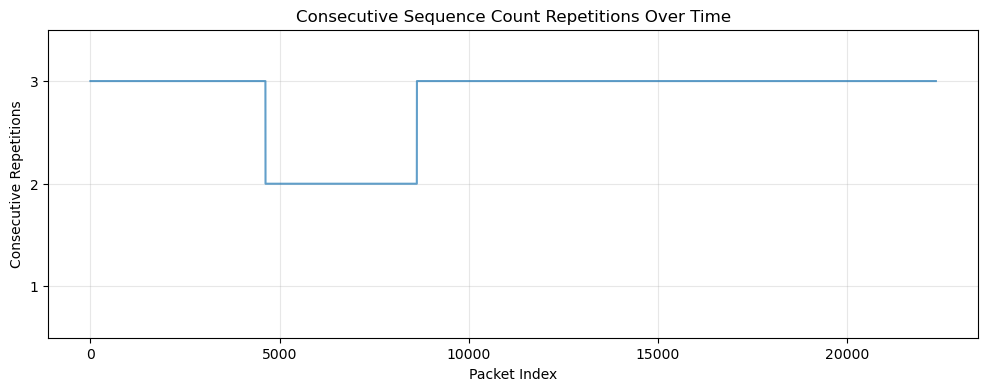


Summary of consecutive repetition patterns:
Length 2: 2001 runs covering 4002 packets (17.9%)
Length 3: 6115 runs covering 18345 packets (82.1%)


In [76]:
# Create array showing run length for each packet
run_length_array = np.zeros(len(seqcounts))
for i, length in enumerate(run_lengths):
    start_idx = change_indices[i]
    end_idx = start_idx + length
    run_length_array[start_idx:end_idx] = length

# Plot the pattern
plt.figure(figsize=(12, 4))
plt.plot(run_length_array, alpha=0.7)
plt.ylabel('Consecutive Repetitions')
plt.xlabel('Packet Index')
plt.title('Consecutive Sequence Count Repetitions Over Time')
plt.ylim(0.5, max(run_length_array) + 0.5)
plt.yticks(range(1, int(max(run_length_array)) + 1))
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
unique_lengths, length_counts = np.unique(run_lengths, return_counts=True)
total_packets = sum(length_counts * unique_lengths)
print(f"\nSummary of consecutive repetition patterns:")
for length, count in zip(unique_lengths, length_counts):
    packets = count * length
    print(f"Length {length}: {count} runs covering {packets} packets ({packets/total_packets*100:.1f}%)")

Data from 09/19: 

In [77]:
hk_ts, cmd_ts = read_file(raw_data_dir / hk_files[-1])

2025-10-28 12:05:27 - swxsoc - INFO: padreMDU8_250919172602.dat: Found housekeeping data
2025-10-28 12:05:27 - swxsoc - INFO: padreMDU8_250919172602.dat: Found read data


INFO: padreMDU8_250919172602.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250919172602.dat: Found read data [padre_meddea.housekeeping.housekeeping]


In [ ]:
hk_ts['time'][0].value, hk_ts['time'][-1].value

('2025-09-19 17:26:07.000', '2025-09-19 17:38:27.000')

In [ ]:
l1_hk_ts, l1_cmd_ts = read_file(l1_hk_files[-1])

In [ ]:
print(len(hk_ts['time']), len(l1_hk_ts['time']))

75 75
